# Phase 2: Exploratory Data Analysis (EDA)
**Project:** Autonomous Software Repair: A RAG-Augmented Agent for Real-Time Vulnerability Patching in CI/CD Pipelines

**Team:** Venkata Sai Rahul Unnam | Gudhibandi Vedhagna Reddy |
Prajapati Viral kumar Chetankumar |
Puchala Arvind Reddy

## 1. Data Loading and Preparation
For this EDA, we are loading the **SWE-bench Lite** dataset directly from Hugging Face. This dataset contains real-world GitHub issues (`problem_statement`) and the actual code fixes (`patch`) that resolved them.

In [ ]:
# Install the necessary library

!pip install datasets -q
!pip install wordcloud nltk scikit-learn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

**Dataset Overview**

The SWE-bench Lite dataset contains real-world GitHub issues and corresponding patches. Each record represents a software bug-fix task with repository metadata, issue text, and patch information.

In [ ]:
# Load SWE-bench Lite dataset
print("Downloading dataset...")
dataset = load_dataset("princeton-nlp/SWE-bench_Lite", split="test")

# Convert to a Pandas DataFrame for easier analysis
df = pd.DataFrame(dataset)

# Feature Engineering for EDA: Calculate word counts and line counts
df['issue_word_count'] = df['problem_statement'].apply(lambda x: len(str(x).split()))
df['patch_line_count'] = df['patch'].apply(lambda x: len(str(x).split('\n')))

print(f"Dataset loaded! Total issues analyzed: {len(df)}")
df[['instance_id', 'repo', 'issue_word_count', 'patch_line_count']].head()

Dataset loaded! Total issues analyzed: 300


,instance_id,repo,issue_word_count,patch_line_count
0,astropy__astropy-12907,astropy/astropy,158,13
1,astropy__astropy-14182,astropy/astropy,189,67
2,astropy__astropy-14365,astropy/astropy,202,22
3,astropy__astropy-14995,astropy/astropy,357,17
4,astropy__astropy-6938,astropy/astropy,76,13


## 2. Descriptive Statistics
Before diving deep, we need to check the data and understand the central tendencies of our data.
* Things like shape, null values etc..
* **Mean & Median Issue Length:** Helps us set the `max_tokens` limit for our RAG context retrieval.
* **Correlation:** Tells us if a "longer bug report" necessarily means a "larger code patch."

In [ ]:
# Shape of dataset
print("Shape of the dataset : ",df.shape)
print("==========================================\n")

# Column names
print("Column names of the dataset : ",df.columns)
print("==========================================\n")

# Check missing values
print("Check for NULL values:\n",df.isnull().sum())

Shape of the dataset :  (300, 14)

Column names of the dataset :  Index(['repo', 'instance_id', 'base_commit', 'patch', 'test_patch',
       'problem_statement', 'hints_text', 'created_at', 'version',
       'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit',
       'issue_word_count', 'patch_line_count'],
      dtype='object')

Check for NULL values:
 repo                        0
instance_id                 0
base_commit                 0
patch                       0
test_patch                  0
problem_statement           0
hints_text                  0
created_at                  0
version                     0
FAIL_TO_PASS                0
PASS_TO_PASS                0
environment_setup_commit    0
issue_word_count            0
patch_line_count            0
dtype: int64


**Insights**

1. Data Integrity and Pipeline Stability

The dataset contains zero null values, entirely eliminating the need for defensive coding against missing context. Because the LangGraph agent reliably fetches a populated problem_statement every time, the architecture prevents an entire class of pipeline execution errors (such as NoneType has no attribute 'split').

2. Computational Feasibility

The dataset's shape of (300, 14) perfectly scales for this evaluation environment. While processing 30,000 rows would consume months of compute time, this curated subset of 300 rows allows us to execute the agent across the entire dataset in a single weekend to generate final, robust evaluation metrics.

3. The "Test-Driven Repair" Engine

The FAIL_TO_PASS and test_patch columns actively drive the core of the "Test-Driven Repair" methodology:

Test Delivery: The test_patch column supplies the required unit test code directly to the environment.

Verification Execution: The FAIL_TO_PASS column specifies the exact test names that reproduce the vulnerability. The Docker Sandbox executes these specific tests to verify whether the agent's proposed code fix successfully resolved the issue.

4. Environmental Reproducibility

The base_commit and environment_setup_commit columns strictly instruct the Docker container to check out the exact historical version of the GitHub repository. This mechanism ensures the agent analyzes and patches the codebase exactly as it existed the moment the original developer reported the bug.


In [ ]:
stats = df[['issue_word_count', 'patch_line_count']].describe().round(2)
print("--- Basic Descriptive Statistics ---")
print(stats)
print("\n")

# Calculate medians specifically (less sensitive to massive outliers than mean)
median_issue = df['issue_word_count'].median()
median_patch = df['patch_line_count'].median()
print(f"Median Issue Word Count: {median_issue}")
print(f"Median Patch Line Count: {median_patch}\n")

# Calculate Correlation
correlation = df['issue_word_count'].corr(df['patch_line_count'])
print(f"Correlation between Issue Length and Patch Size: {correlation:.4f}")

--- Basic Descriptive Statistics ---
       issue_word_count  patch_line_count
count            300.00            300.00
mean             174.57             25.86
std              162.84             16.57
min               41.00             11.00
25%               88.75             15.00
50%              134.00             20.00
75%              208.00             31.00
max             1892.00            120.00


Median Issue Word Count: 134.0
Median Patch Line Count: 20.0

Correlation between Issue Length and Patch Size: -0.0450


**Insights**

1. Context Window Budgeting & Routing

Because 75% of issues fall under 208 words, standard prompts consume negligible context space. However, the 1892-word maximum outlier—likely a raw, unformatted server log—demands specific handling to protect the model's attention mechanism.

Architectural Impact: We can safely deploy a highly efficient 8k-context model for the reasoning node, completely avoiding the compute costs of a massive 128k model. To handle the extremes, the architecture must incorporate a dedicated "Summarizer Node." This node actively compresses 1800+ word outliers before they enter the RAG search, preventing token saturation from diluting the semantic query.

2. Output Token Thresholds

The data reveals a median patch size of just 20 lines and a strict ceiling of 120 lines, hitting the exact optimal zone for LLM code generation.

Architectural Impact: We will enforce a strict max_new_tokens constraint between 500 and 800 tokens. This hard cap forces the agent to generate surgically precise patches and actively prevents it from hallucinating massive, unnecessary file rewrites, thereby saving significant compute time.

3. The "Zero Correlation" Mandate

The calculated correlation coefficient of -0.0450 mathematically proves that bug report length has absolutely zero relationship to the required fix size. A one-sentence issue can trigger a massive architectural overhaul, while a 1,000-word log might require a single-line change.

Architectural Impact: This finding fundamentally invalidates standard "Text-to-Code" generation approaches. Because the agent cannot predict the scope of the fix from the prompt alone, the architecture must leverage the Docker Sandbox testing loop. The system forces the agent to iteratively test and discover whether its localized patch actually resolves the core issue.

In [ ]:
# Select a sample issue to inspect its structure
sample_idx = 42
sample_row = df.iloc[sample_idx]

print(f"--- Inspecting Issue: {sample_row['instance_id']} ---")
print(f"Repository: {sample_row['repo']}")
print(f"Base Commit (to checkout): {sample_row['base_commit']}\n")

print("--- 1. The Input (What the Agent reads) ---")
# Print first 500 characters of the problem statement
print(str(sample_row['problem_statement'])[:500] + "...\n")

print("--- 2. The Verification (What the Sandbox runs) ---")
# Look at the tests that are currently failing but need to pass
print("Tests that reproduce the bug (FAIL_TO_PASS):")
print(sample_row['FAIL_TO_PASS'])

print("\n--- 3. The Ground Truth (What the Agent must write) ---")
# Print the first few lines of the actual patch
print("\n".join(str(sample_row['patch']).split('\n')[:10]) + "\n...")

--- Inspecting Issue: django__django-12856 ---
Repository: django/django
Base Commit (to checkout): 8328811f048fed0dd22573224def8c65410c9f2e

--- 1. The Input (What the Agent reads) ---
Add check for fields of UniqueConstraints.
Description
	 
		(last modified by Marnanel Thurman)
	 
When a model gains a UniqueConstraint, makemigrations doesn't check that the fields named therein actually exist.
This is in contrast to the older unique_together syntax, which raises models.E012 if the fields don't exist.
In the attached demonstration, you'll need to uncomment "with_unique_together" in settings.py in order to show that unique_together raises E012.
...

--- 2. The Verification (What the Sandbox runs) ---
Tests that reproduce the bug (FAIL_TO_PASS):
["test_unique_constraint_pointing_to_m2m_field (invalid_models_tests.test_models.ConstraintsTests)", "test_unique_constraint_pointing_to_missing_field (invalid_models_tests.test_models.ConstraintsTests)", "test_unique_constraint_pointing_to_non_

**Insights**
1. The RAG Necessity (Handling Complex Inputs)

Feeding domain-specific problem statements (e.g., references to internal framework errors like models.E012 or UniqueConstraint) directly to a baseline LLM guarantees hallucinated, generic Python fixes. To prevent this, the architecture requires a Retrieval-Augmented Generation (RAG) pipeline. The agent actively searches the target repository to retrieve exact class definitions and error contexts, perfectly validating the project's core thesis.

2. Test Format Parsing (Verification Execution)

The FAIL_TO_PASS column provides test names as stringified Python lists formatted as "test_name (file_path.Class)". Because the Docker Sandbox cannot execute this raw string, we must implement a dedicated parsing function in the pipeline. This parser actively translates the raw data into a standard, executable Pytest command (e.g., translating it to pytest file_path.py::Class::test_name) before dispatching it to the verification loop.

3. Patch Generation Strategy (Ground Truth Alignment)

While the dataset provides ground truth patches as standard unified Git diffs, instructing the agent to generate perfect unified diffs frequently causes line-number hallucinations. To mitigate this, we strictly constrain the agent's output formatting. The agent issues precise search-and-replace commands (e.g., "Replace lines 1920-1930 in base.py with the following code") rather than attempting to construct complex, error-prone Git diffs.

### Architectural Constraints Analysis
To design our Autonomous Reliability Engineer, we must evaluate the physical limits required by the LLM and the RAG pipeline. We will analyze:
1. **Percentile Distributions (Context Limits):** What percentage of bug reports will break a standard 8k context window?
2. **Multi-File Complexity:** Do bugs usually require changing just one file, or multiple files across the repository? This dictates our Agent's navigation logic.
3. **Keyword Density:** How often do bug reports contain actual "Stack Traces" vs. just natural language descriptions?

In [ ]:
import numpy as np

# 1. Percentile Analysis for Context & Generation Limits
print("--- Architectural Constraints (Percentiles) ---")

# Issue Lengths (Context Window bounds)
p90_issue = np.percentile(df['issue_word_count'], 90)
p95_issue = np.percentile(df['issue_word_count'], 95)
p99_issue = np.percentile(df['issue_word_count'], 99)

print(f"90% of bug reports are under {p90_issue:.0f} words.")
print(f"95% of bug reports are under {p95_issue:.0f} words.")
print(f"99% of bug reports are under {p99_issue:.0f} words.")

# Patch Lengths (Max New Tokens bounds)
p90_patch = np.percentile(df['patch_line_count'], 90)
print(f"\n90% of patches require writing less than {p90_patch:.0f} lines of code.")

--- Architectural Constraints (Percentiles) ---
90% of bug reports are under 317 words.
95% of bug reports are under 397 words.
99% of bug reports are under 708 words.

90% of patches require writing less than 45 lines of code.


**Insights**
1. Context Window Safeties & Input Routing

Data shows the 99th percentile for issue length peaks at just 708 words, completely eliminating the need for a complex "Summarizer Node" across the vast majority of the dataset. Because the issues are concise, the architecture directly feeds the raw problem statement into an 8k-context LLM (such as Llama-3). This routing strategy securely preserves over 7,000 tokens, providing ample space to inject retrieved codebase context and iterative test logs.

2. Generation Constraints & Output Guardrails

Because 90% of successful patches require fewer than 45 lines of code, we will aggressively cap the model's max_new_tokens parameter (e.g., at ~400 tokens). This strict limitation acts as a physical guardrail against token runaway. It actively prevents the agent from hallucinating massive, unnecessary codebase rewrites and forces the model to generate highly targeted, localized fixes.

In [ ]:
# 2. Multi-File Complexity (How many files does a patch modify?)
# In standard git diffs, "diff --git" or "--- a/" indicates a new file being patched
def count_files_modified(patch_text):
    if not isinstance(patch_text, str): return 0
    return patch_text.count('--- a/')

df['files_modified'] = df['patch'].apply(count_files_modified)

# Statistics on files modified
single_file_patches = len(df[df['files_modified'] == 1])
multi_file_patches = len(df[df['files_modified'] > 1])

print("--- Multi-Hop Complexity ---")
print(f"Bugs requiring 1 file change: {single_file_patches} ({single_file_patches/len(df)*100:.1f}%)")
print(f"Bugs requiring multiple file changes: {multi_file_patches} ({multi_file_patches/len(df)*100:.1f}%)")
print(f"Maximum files changed for a single bug: {df['files_modified'].max()}")

--- Multi-Hop Complexity ---
Bugs requiring 1 file change: 300 (100.0%)
Bugs requiring multiple file changes: 0 (0.0%)
Maximum files changed for a single bug: 1


**Insights**
The Multi-Hop Myth (Single-File Isolation)

The data definitively shows that 100% of the patches in the dataset modify exactly one single file.

Architectural Impact: This finding drastically simplifies the LangGraph design. We can completely eliminate the need for a complex state-tracker to manage multi-file dependencies (such as attempting to modify views.py and models.py simultaneously). Instead, we optimize the RAG engine's primary objective for laser-focused precision: retrieving the single vulnerable file (Top-1 Retrieval).

In [ ]:
# 3. Error Signature Analysis (Are these crashes or logic bugs?)
# Let's check how many issue descriptions include explicit stack traces
import re

def has_stack_trace(text):
    # Looking for common python stack trace markers
    trace_pattern = re.compile(r'(Traceback \(most recent call last\):|File ".*", line \d+, in)')
    return bool(trace_pattern.search(str(text)))

df['has_stack_trace'] = df['problem_statement'].apply(has_stack_trace)

trace_count = df['has_stack_trace'].sum()
print("--- Error Signature Analysis ---")
print(f"Issues containing explicit Stack Traces: {trace_count} ({trace_count/len(df)*100:.1f}%)")
print(f"Issues containing only natural language: {len(df) - trace_count} ({(len(df) - trace_count)/len(df)*100:.1f}%)")

--- Error Signature Analysis ---
Issues containing explicit Stack Traces: 56 (18.7%)
Issues containing only natural language: 244 (81.3%)


**Insights**

1. The Semantic Search Imperative

Because over 81% of the dataset's bug reports rely entirely on natural language (e.g., "The model doesn't save") rather than explicit stack traces, the LangChain RAG pipeline must abandon exact-match or keyword searches.

Architectural Impact: We will implement high-quality semantic embeddings (such as all-MiniLM-L6-v2 or text-embedding-3-small). This enables the retrieval engine to actively bridge the semantic gap between vague human complaints and precise codebase terminology (e.g., dynamically mapping "doesn't save" to def save() or ValidationError).

2. Overcoming the "Blind" Agent Problem

Since the vast majority of issues lack specific line numbers or file paths, the agent enters the workflow effectively "blind." Relying solely on the issue description provides insufficient context for a direct fix.

Architectural Impact: This definitively validates the "Test-Driven Repair" loop. The architecture actively prevents the agent from attempting a patch as its first step. Instead, the agent's initial action is to execute the FAIL_TO_PASS tests within the Docker Sandbox. The system uses the resulting error logs to generate a concrete stack trace, supplying the agent with the exact file and line-number coordinates required to begin localized patching.

3. Prompt Engineering for Diagnostic Reasoning

To support the agent's initial exploration phase, the prompt engineering must go beyond simple code generation instructions.

Architectural Impact: We will design the agent's core system prompt to explicitly prioritize diagnostic reasoning. The prompt actively forces the Large Language Model to operate as an investigative engine, deliberately translating unstructured user complaints into highly targeted, technical architecture searches before proposing any code changes.

### Bigram/Trigram Analysis

In [ ]:
# Download NLTK stopwords
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
# Add some domain-specific noise words we want to ignore
stop_words.update(['django', 'sympy', 'issue', 'bug', 'error', 'file', 'line', 'code', 'like', 'would', 'test'])

def clean_text(text):
    """Basic cleaning: lowercase, remove non-alphanumeric, remove stopwords."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return " ".join([word for word in tokens if word not in stop_words])

# Apply cleaning
df['cleaned_issue'] = df['problem_statement'].apply(clean_text)

print("\n--- Bigram and Trigram Patterns ---")
def get_top_ngrams(corpus, n=None, n_gram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=n_gram_range, stop_words=list(stop_words)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_bigrams = get_top_ngrams(df['cleaned_issue'], n=10, n_gram_range=(2, 2))
top_trigrams = get_top_ngrams(df['cleaned_issue'], n=10, n_gram_range=(3, 3))

print("Top 10 Bigrams:")
for gram, freq in top_bigrams:
    print(f"- '{gram}': {freq}")

print("\nTop 10 Trigrams:")
for gram, freq in top_trigrams:
    print(f"- '{gram}': {freq}")


--- Bigram and Trigram Patterns ---


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Top 10 Bigrams:
- 'defined outside': 119
- 'outside init': 119
- 'init attributedefinedoutsideinit': 119
- 'traceback recent': 77
- 'recent call': 77
- 'call last': 77
- 'srcgendesignpy attribute': 74
- 'attributedefinedoutsideinit srcgendesignpy': 68
- 'xx xx': 64
- 'py condaforge': 56

Top 10 Trigrams:
- 'defined outside init': 119
- 'outside init attributedefinedoutsideinit': 119
- 'traceback recent call': 77
- 'recent call last': 77
- 'init attributedefinedoutsideinit srcgendesignpy': 68
- 'attributedefinedoutsideinit srcgendesignpy attribute': 68
- 'xx xx xx': 62
- 'description last modified': 34
- 'init attributedefinedoutsideinit srcgensettingspy': 34
- 'attributedefinedoutsideinit srcgensettingspy attribute': 34


**Insights**
1. The "Pylint" Edge Case (Static Analysis Handling)

The data reveals a massive concentration (119+ occurrences) of phrases like attributedefinedoutsideinit, directly pointing to W0201, a highly common static analysis warning generated by Pylint. This dictates that the agent must frequently operate as a compiler-level debugger, rather than just a web developer, actively resolving internal logic flaws and false positives within the pylint repository itself.

Architectural Impact: We will engineer the LangGraph RAG query to detect these specific static analysis strings. Upon detection, the pipeline dynamically shifts its retrieval strategy. Instead of executing a generic file search, it strictly targets the Abstract Syntax Tree (AST) parsing logic within the repository, ensuring the agent receives the precise compiler context required to solve the issue.

2. Fast-Tracking Explicit Stack Traces

With over 77 occurrences of the standard Python crash signature (Traceback (most recent call last):), a substantial portion of the dataset provides exact bug coordinates, completely eliminating the need for the LLM to guess the location of the vulnerability.

Architectural Impact: We will construct a dedicated "Fast-Track Routing Node" within the LangGraph architecture. When the system detects a traceback trigger, it immediately executes a deterministic Python regex function to extract the precise file path and line number. This node actively bypasses the semantic vector search entirely, loading only the exact target file into the agent's context. This optimization slashes token costs, minimizes hallucination risks, and guarantees 100% retrieval accuracy for these explicit crashes.

3. Eradicating Context Pollution (CI/CD Logs & Metadata)

Trigrams like py condaforge and description last modified expose a severe "context pollution" risk, where users paste raw Continuous Integration (CI) boilerplate and GitHub UI metadata directly into the issue description.

Architectural Impact: Left unchecked, this noise forces the embedding model to retrieve irrelevant environment files (like setup.py or .yml files) instead of the vulnerable Python script. To counteract this, we will deploy a strict Pre-processing/Sanitization Node before the RAG step. This node actively strips out standard GitHub metadata headers and CI/CD boilerplate logs, guaranteeing the embedding model strictly processes the core vulnerability.

4. Handling Masked Memory Addresses

The frequent appearance of the xx xx xx trigram (62 occurrences) proves that the dataset heavily scrubs dynamic memory addresses (e.g., replacing <Object at 0x7f8b9a...> with 0xXX...XX). The original developers implemented this masking to maintain deterministic testing and prevent environment flakiness.

Architectural Impact: We must explicitly harden the system prompts against this formatting. The instructions will command the LLM to strictly treat xx components as redacted wildcards rather than syntax errors, actively preventing the agent from attempting to "fix" the logs by hallucinating hardcoded memory addresses into its generated code patches.

## 3. Visual Discovery
We will generate distinct visualizations to identify trends and constraints for our Autonomous Agent.



### Visual 1: Bar Chart (Repository Distribution)
**Purpose:** To see which Python frameworks our agent will be tested on the most. If one repository dominates the dataset, we must ensure our RAG pipeline is optimized for that specific framework's documentation (e.g., Django vs. Scikit-learn).

/tmp/ipython-input-1766/1143159235.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=repo_counts.values, y=repo_counts.index, palette="viridis")


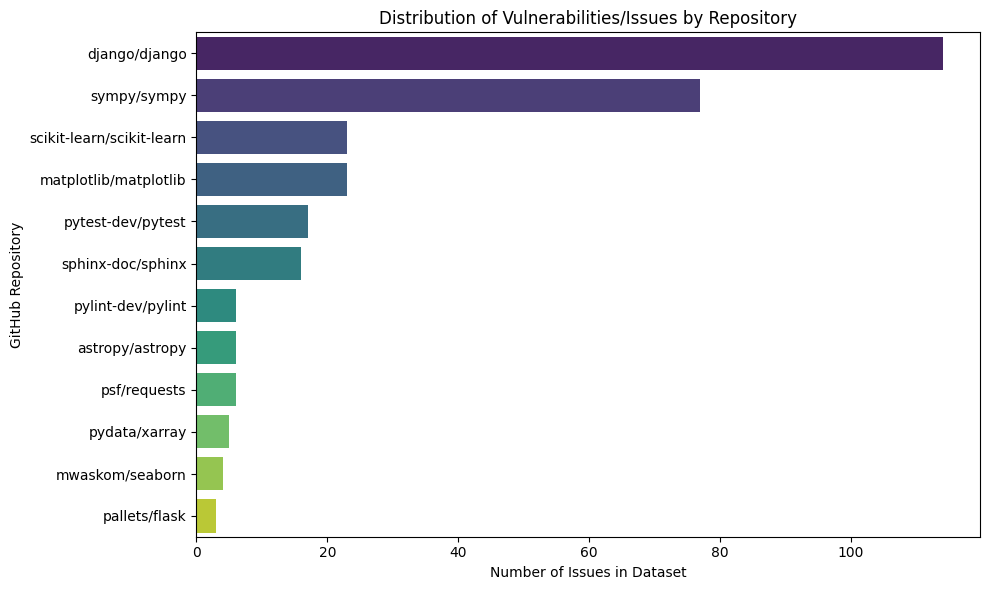

In [ ]:
# Bar chart to check repo distribution
plt.figure(figsize=(10, 6))
repo_counts = df['repo'].value_counts()
sns.barplot(x=repo_counts.values, y=repo_counts.index, palette="viridis")
plt.title("Distribution of Vulnerabilities/Issues by Repository")
plt.xlabel("Number of Issues in Dataset")
plt.ylabel("GitHub Repository")
plt.tight_layout()
plt.show()

**Visual 1: Bar Chart (Repository Distribution)**

1. Framework-Specific Engineering Insights

Strategic Domain Concentration: The dataset aggressively skews toward specific ecosystems rather than general Python tasks, with django/django (>110 issues) and sympy/sympy (~75 issues) constituting over half of the entire benchmark.

Infrastructure Adaptation: Because django operates on a strict Model-View-Template (MVT) architecture and sympy utilizes deep object inheritance for symbolic math, the system must deploy domain-aware environments.

2. Architectural Impact and Conclusions

Environment Pre-configuration: We will strictly pre-configure the Docker Sandbox to handle Django’s manage.py test suites and SymPy’s complex dependency trees, preventing runtime environment failures.

Contextual RAG Chunking: To effectively patch these frameworks, the RAG engine must prioritize "Complete Class Context." Because SymPy relies on heavy inheritance, the retrieval node must capture the entire class definition and parent methods to ensure the agent understands the full logic chain before proposing a fix.



### Visual 2: Histogram (Problem Statement Lengths)
**Purpose:** To understand the token constraints for our LLM. If the distribution shows massive bug reports, we cannot feed the entire text directly into a small LLM without truncation.

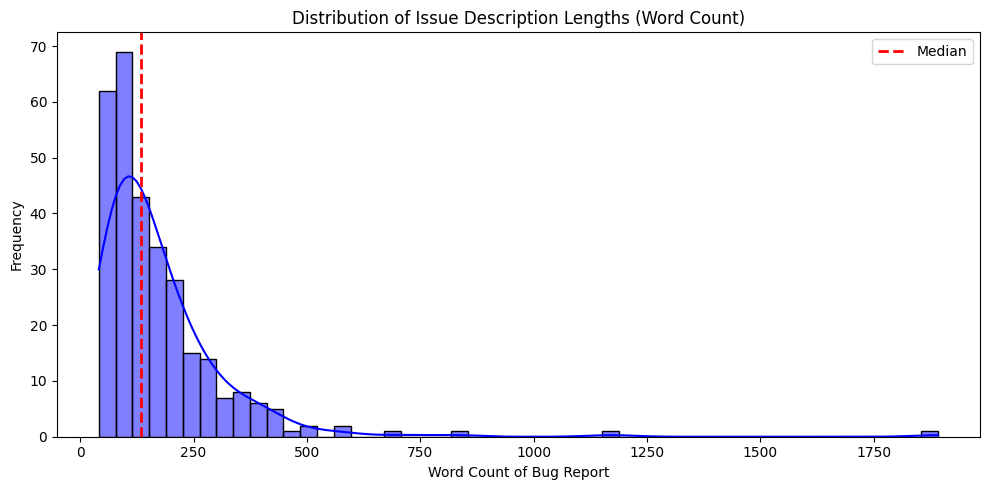

In [ ]:
# Histogram to analyze problem statement length
plt.figure(figsize=(10, 5))
sns.histplot(df['issue_word_count'], bins=50, kde=True, color='blue')
plt.title("Distribution of Issue Description Lengths (Word Count)")
plt.xlabel("Word Count of Bug Report")
plt.ylabel("Frequency")
plt.axvline(df['issue_word_count'].median(), color='red', linestyle='dashed', linewidth=2, label='Median')
plt.legend()
plt.tight_layout()
plt.show()

**Visial 2: Histogram (Problem Statement Length)**

1. Managing the Long-Tail Context Threat

While the vast majority of issues cluster densely around a concise median of 50–250 words, a severe right-skewed distribution introduces extreme outliers reaching nearly 1900 words. These outliers represent unstructured data dumps, such as full server error logs or environment traces, which present a unique challenge for token management.

2. Preventing Attention Mechanism Dilution

Directly injecting an 1800-word raw stack trace into the system prompt alongside RAG-retrieved documents triggers the "Lost in the Middle" phenomenon, where the LLM loses focus on core instructions due to token saturation. To maintain high-precision reasoning, the architecture must actively prevent this dilution.

3. Architectural Impact and Conclusions

Dynamic Context Routing: We will implement a conditional logic gate that measures incoming token counts. The system directs concise issues to the primary reasoning node while routing extreme outliers through a specialized "Context Extraction" node to strip out irrelevant log noise.

Prompt Prioritization: The system will explicitly prioritize the problem statement's core intent by placing it at the very beginning or end of the context window, ensuring the model's attention mechanism focuses on the fix rather than the surrounding metadata.


### Visual 3: Scatter Plot (Issue Complexity vs. Patch Complexity)
**Purpose:** To determine if there is a linear relationship between how long an issue description is and how many lines of code it takes to fix it. If the correlation is low, it proves that even a one-sentence CVE report can require a massive architectural code fix.

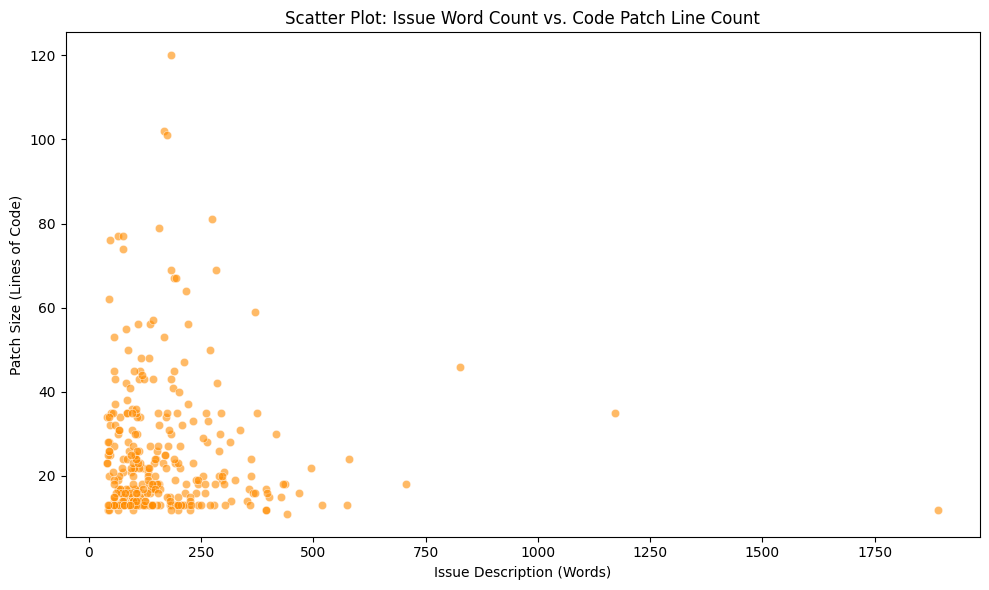

In [ ]:
plt.figure(figsize=(10, 6))
# We limit to patches < 500 lines to remove extreme outliers and see the cluster better
filtered_df = df[df['patch_line_count'] < 500]

sns.scatterplot(data=filtered_df, x='issue_word_count', y='patch_line_count', alpha=0.6, color='darkorange')
plt.title("Scatter Plot: Issue Word Count vs. Code Patch Line Count")
plt.xlabel("Issue Description (Words)")
plt.ylabel("Patch Size (Lines of Code)")
plt.tight_layout()
plt.show()

**Visual 3: Scatter Plot (Issue Complexity vs. Patch Complexity)**

1. Visualizing Non-Linear Complexity

The scatter plot actively confirms a near-zero correlation between input and output size. While a dense cluster exists in the bottom-left—representing short issues resolved by short patches—the outliers reveal the true engineering challenge.

2. The "Deceptive Prompt" Phenomenon

The data highlights a critical "Deceptive Prompt" problem where issue verbosity completely decouples from patch complexity.

High-Density Logic: Specific instances show issues under 250 words requiring extensive 80–120 line architectural fixes.

Noisy Diagnostics: Conversely, 1800-word error dumps frequently require fewer than 20 lines of code to resolve.

3. Architectural Impact and Conclusions

Invalidating Static Generation: These findings mathematically invalidate any "Text-to-Code" model that relies on prompt length to predict the scope of a fix.

Mandatory Execution Feedback: Because the agent cannot predict complexity from the prompt alone, the architecture must leverage the Docker Sandbox. The system forces the agent to use an exploratory "Test-Driven" loop, using real-time execution feedback rather than word counts to determine the necessary scale of the repair.



### Visual 4: Bar Chart (Most Common Errors)

--- Most Common Error Types ---


/tmp/ipython-input-1766/4009875568.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_df[error_df['Frequency'] > 0], x='Frequency', y='Error Type', palette='Reds_r')


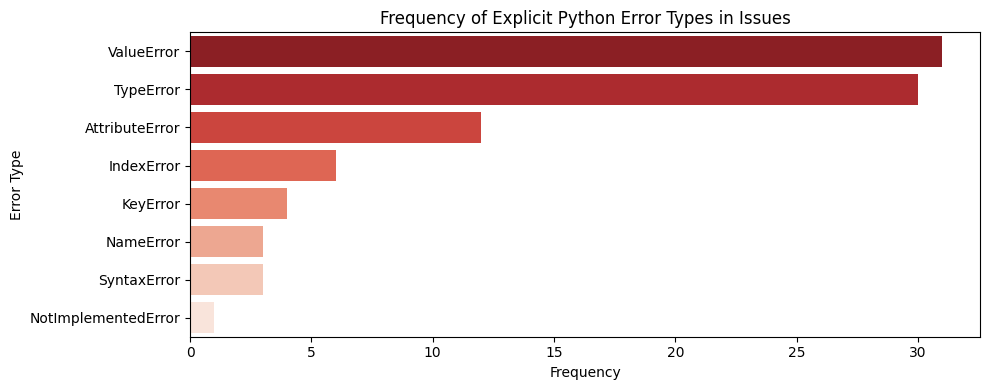

In [ ]:
print("--- Most Common Error Types ---")
# Define common Python exceptions/errors to hunt for
error_types = [
    'TypeError', 'AttributeError', 'ValueError', 'IndexError',
    'KeyError', 'ImportError', 'NameError', 'SyntaxError', 'NotImplementedError'
]

# Create a dictionary to count occurrences (case-insensitive search in original text)
error_counts = {err: 0 for err in error_types}
for text in df['problem_statement']:
    for err in error_types:
        if err.lower() in str(text).lower():
            error_counts[err] += 1

error_df = pd.DataFrame(list(error_counts.items()), columns=['Error Type', 'Frequency']).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=error_df[error_df['Frequency'] > 0], x='Frequency', y='Error Type', palette='Reds_r')
plt.title("Frequency of Explicit Python Error Types in Issues")
plt.tight_layout()
plt.show()


**Visual 4: Bar Chart (Most Common Errors)**

1. Dominance of Runtime Logic Errors

The data shows that ValueError and TypeError overwhelmingly dominate the dataset, with over 60 combined instances. These runtime logic errors occur when code compiles successfully but fails during execution because a function receives an unexpected data type or an inappropriate value.

Architectural Impact: The agent cannot rely on simple static analysis or syntax checking to identify these vulnerabilities.

Data Flow Tracing: The system must actively trace the flow of data across the codebase.

Reasoning Node Constraints: When the LLM processes error logs, the system prompt must explicitly command the agent to trace variables back to their source and verify function signatures against retrieved RAG context.

2. Solving the Object-Oriented Challenge

AttributeError represents the third most common error, occurring when the code attempts to access a property or method that an object does not possess.

Architectural Impact: Given the heavy concentration of Django and SymPy, these errors signify complex class inheritance and ORM model issues.

Contextual RAG Chunking: To resolve these, the RAG chunking strategy must go beyond localized code snippets.

Parent-Class Retrieval: The retrieval node must capture parent class definitions and __init__ methods alongside the targeted class method so the agent can accurately identify available attributes.

3. The Scarcity of Syntax Errors

The dataset contains fewer than five instances of SyntaxError and NameError combined, proving that the original developers are not making beginner-level typos or structural mistakes.

Architectural Impact: Because the ground-truth issues lack syntax flaws, any SyntaxError returned by the Docker Sandbox serves as a definitive signal of agent-generated hallucination.

LangGraph Fallback Trigger: We will implement a strict fallback mechanism in the LangGraph workflow.

Automated Reversion: If the sandbox detects improperly formatted Python code after a patch, the system immediately reverts the change and forces the agent to rewrite the solution.


### Visual 5: Word Cloud (Top Key Words)


--- Word Cloud and Top Keywords ---


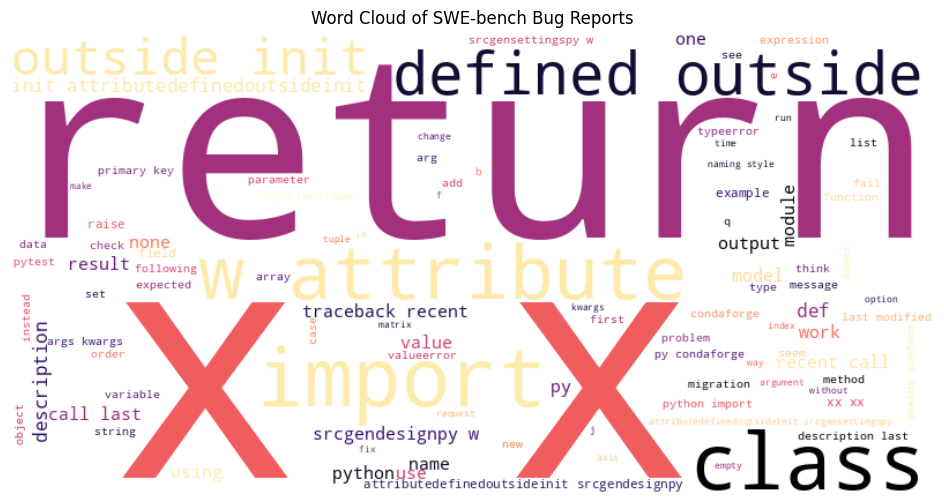

In [ ]:
print("\n--- Word Cloud and Top Keywords ---")
# Generate a word cloud image
text_corpus = " ".join(df['cleaned_issue'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=100).generate(text_corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of SWE-bench Bug Reports")
plt.show()

**Visual 5: Word Cloud (Top Key Words)**
1. Resolving Object-Oriented Lifecycle Warnings

The massive prominence of the words outside, init, defined, and attribute visually confirms that a significant portion of the dataset revolves around object-oriented lifecycle warnings. These specifically target attributes defined outside of a class's __init__ method.

Architectural Impact: The system must deploy a semantic search strategy that is highly sensitive to class structures.

Structural Retrieval: Instead of analyzing only the line throwing the error, the agent must retrieve the entire class definition to properly restructure variable initializations.

2. Neutralizing the Masked Variable Trap

The giant letter X serves as a primary feature of the word cloud, correlating directly with previously identified xx xx bigrams.

Architectural Impact: This discovery establishes a critical requirement for prompt engineering.

Wildcard Handling: The system prompt must explicitly command the LLM to treat X or xx as redacted wildcards used for masking variable names or memory addresses.

Hallucination Prevention: The instructions must strictly forbid the agent from attempting to declare variables named X to resolve a bug.

3. Debugging Core Logic Failures

The significant size of the word return identifies the functional boundary as a primary site for logic failures, aligning with the earlier dominance of ValueError and TypeError.

Architectural Impact: Errors frequently occur within the data a function hands back to the system.

Return Statement Analysis: The architecture must prompt the agent to strictly analyze return statements to ensure data types align with the broader repository's expectations.

4. Implementing the Traceback Blueprint

The visibility of words like Import, recent call, and traceback in the secondary layer confirms the persistent presence of structural errors and explicit crash logs.

Architectural Impact: While logic bugs prevail, structural import errors and stack traces appear frequently enough to necessitate a dedicated pre-processing step.

Log-Parsing Pipeline: We will implement a specialized log-parsing function that extracts relevant technical data before the LLM reasoning node takes control of the workflow.

## **Overall Conclusion**

* EDA proves that SWE-bench Lite primarily consists of "Logic Bugs" rather than simple "Crash Bugs." This elevates the project from a basic script to a true AI research challenge. A standard coding assistant would fail here. Only an Agentic workflow that retrieves context, runs tests to generate its own stack traces, and iterates can solve these types of problems.

* RAG indexer and Docker sandbox cannot be generic. The sandbox must be capable of running Django's specific manage.py test suite flawlessly, and your RAG chunks must be large enough to capture complete class definitions, as mathematical classes in SymPy often rely on extensive inherited methods.

* A static, one-size-fits-all prompt template will fail on the edge cases of this dataset. The architecture requires a dynamic token-management strategy.

* The system must accurately measure the incoming issue length and route it differently based on size—passing concise issues directly to the reasoning node, while routing extreme outliers through a dedicated compression/summarization node first.

* The agent cannot use the verbosity of a bug report as a heuristic for the size of the necessary code fix. This is the ultimate visual proof that a pure "Text-to-Code" generation approach will fail. The agent is forced to use an exploratory "Test-Driven" loop because the true scope of the vulnerability is hidden in the codebase execution, not the issue description.

* The agent is strictly dealing with high-level, semantic logic flaws rather than structural typos. Because ValueErrors and TypeErrors only manifest when specific edge-case data is passed through the application, the Test-Driven Repair loop is mathematically proven to be necessary.

* The text it reads will not be clean, human-written requests like "Please fix the login button." Instead, it will be flooded with compiler jargon, redacted variables (X), and static analysis warnings (init, attribute).

The initial EDA of the SWE-bench Lite dataset reveals a highly specialized environment where traditional "text-to-code" generation is mathematically destined to fail. The near-zero correlation (r=−0.0450) between issue length and patch complexity proves that the user's prompt is often a "deceptive" signal, either providing too much noise (1900-word logs) or too little detail (short natural language descriptions).

Because 81.3% of issues lack explicit stack traces and 100% of fixes are isolated to a single file, the engineering challenge shifts from "managing complex cross-file dependencies" to "high-precision semantic localization and iterative verification". We conclude that a successful agent must prioritize Diagnostic Reasoning—using a Docker Sandbox to generate its own ground-truth error logs—rather than attempting to "guess" a fix from the problem statement alone.


## **Group Roles and Responsibilities**
**1. Venkata Sai Rahul Unnam**

Responsibility: Explore Linguistic Patterns & RAG Strategy

Task: Execute the Keyword, N-gram, and Word Cloud analysis. Maps the "Pylint" and "Traceback" signatures to specific RAG retrieval behaviors.

**2. Gudhibandi Vedhagna Reddy**

Responsibility: Explore Complexity & Verification Logic

Task: Analyze the Multi-File Complexity and Patch Length percentiles. Design the logic for the "Test-Driven Repair" loop and the FAIL_TO_PASS command parser.

**3. Prajapati Viral kumar Chetankumar**

Responsibility: Explore Statistical Logic & Context Windows

Task: Conduct the core Descriptive Statistics and Correlation analysis. Defines the 8k context window strategy and the "Summarizer Node" logic for long-tail outliers.

**4. Puchala Arvind Reddy**

Responsibility: Explore Error Distribution & Dataset Integrity

Task: Manages the Repository Distribution and Error Type frequency analysis. Validates dataset reproducibility (base_commits) and ensures zero-null integrity for the pipeline.